In [47]:
#Generate csv file for average time
#Branch33-01
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

os.chdir("/Users/dinguyen/Desktop/Local Documents/GitHub/Paper5/PythonConversion/")
N = 30

# N30	
# ins = [1,2,5,6,7,8,9,10,11,12]
# ins = [4,20,83,99,107,166,172,174,200,241]
# ins = [3,35,36,37,52,63,64,150, 282,319]
ins = [1,2,5,6,7,8,9,10,11,12,4,20,83,99,107,166,172,174,200,241,3,35,36,37,52,63,64,150, 282,319]


# N40	
# ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13]
# ins =  [4, 8, 16, 27, 33, 36, 37, 48, 64, 68]
# ins =  [2, 14, 18, 22, 24, 38, 39, 40, 56, 76]
# ins = [1, 3, 5, 6, 7, 9, 10, 11, 12, 13,4, 8, 16, 27, 33, 36, 37, 48, 64, 68,2, 14, 18, 22, 24, 38, 39, 40, 56, 76]


# N50	
# ins =  [2, 6, 7, 10, 13, 14, 15, 16, 17, 21]
# ins =  [18, 26, 46, 73, 93, 98, 110, 113, 122, 124]
# ins =  [1, 3, 4, 5, 8, 9, 11, 12, 19, 20]
# ins =  [2, 6, 7, 10, 13, 14, 15, 16, 17, 21,18, 26, 46, 73, 93, 98, 110, 113, 122, 124,1, 3, 4, 5, 8, 9, 11, 12, 19, 20]

def processMain(N, ins):
    fileNames = []
    for i in ins:
        fileNames.append("./Dec2024_Output/Iter/main_singleCut_15_N"+str(N)+"_"+str(i)+".txt")
        # fileNames.append("./Iter/main_A3_0_15_N"+str(N)+"_"+str(i)+".txt")
    # print(fileNames)
    # Use the next line for finished ins
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A3_0_15_N"+str(N)+"_")]
    # prefixed = [filename for filename in os.listdir('./') if filename.startswith("main_A2_1_15_N"+str(N)+"_")]
    #Use the one below for Iter
    # prefixed = [filename for filename in os.listdir('./Iter/') if filename.startswith("main_20_N"+str(N)+"_")]
    # print(prefixed)
    # dfs_list = [pd.read_csv(file, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None) for file in prefixed]
    # print(dfs_list[0])
    dfs_list = []
    for filename in fileNames:
        # print(filename)
        split = filename.split("_")[-1].split(".")[0]
        # print(split)  
        # Use the next line for finished ins
        try: 
            num_rows = sum(1 for line in open(filename))
            
            df = pd.read_csv(''+filename, sep=';', names=['Status','iiter','total_time','b','ObjVal','LB','x_sol', 'Kbar', 'K'], header=None)
            # Use the one below for Iter collection
            # df = pd.read_csv('./Iter/'+filename, sep=';', names=['iiter','total_time','b','ObjVal','x_sol'], header=None)
            idx = df.index[df['iiter'] == 1].max()
            print(idx)
            df = df[idx:]
            df['Ins'] = split
            df['Ins'] = df['Ins'].astype(int)
            df["elapsedT"] = df['total_time'].diff(-1).abs()
            df = df.iloc[:-1]
            dfs_list.append(df)
        except:
            print("File "+filename+" does not exist.")
        # print(df)
    df_filtered = pd.concat(dfs_list, axis=0, ignore_index=True)
    
    # df_filtered['max'] = df_filtered.groupby('Ins')['iiter'].transform('max')
    
    # df_filtered = df_filtered[~df_filtered['Ins'].isin(ins_not_terminate)]
    # df_filtered = df_filtered.groupby('Ins').apply(
    #     lambda group: group[group['total_time'] == group['total_time'].max()])
    # df_filtered = df_filtered.reset_index(drop=True)
    df_filtered["OptGap"] = (df_filtered.ObjVal-df_filtered.LB)/df_filtered.ObjVal*100
    
    print("Average Sol Time ", df_filtered['total_time'].mean())
    print("Average |K| ", df_filtered['K'].mean())
    print("Average Opt Gap ", df_filtered["OptGap"].mean(),"%")
    print("Average Iter", df_filtered["iiter"].mean()+1)
    print("Number of solved ins ", len(df_filtered))
    
    

    # print(output)
    # for i in range(5):
    #     output = pd.read_csv(EXP+"_N"+str(N)+"_"+str(i+1)+".txt", sep=";", header=None)
        
    return df_filtered

df_default = processMain(N,ins)
df_default
df_default.to_csv('N'+str(N)+'_timeperitervscell_singleCut.csv', index=False)
# df_default[(df_default.total_time >= 300) &(df_default.total_time <= 3600)]
# df_default[(df_default.total_time < 300)]
# print(list(df_default[(df_default.total_time >= 300) &(df_default.total_time <= 3600)]['Ins']))

6
18
31
8
4
8
9
9
33
10
308
90
94
0
90
139
61
116
50
111
46
113
52
35
50
78
46
79
96
83
Average Sol Time  12.49242314371605
Average |K|  168.3398058252427
Average Opt Gap  26.001778967492548 %
Average Iter 28.66235167206041
Number of solved ins  927


In [108]:
ins_set=[40]
min_K = 0
fileNames = []
for N in ins_set:
        fileNames.append('N'+str(N)+'_timeperitervscell_singleCut.csv')
print(fileNames)
# Read each CSV and concatenate them vertically
df_single = pd.concat([pd.read_csv(f) for f in fileNames], ignore_index=True)
df_single = df_single[df_single.K>min_K]

fileNames = []
for N in ins_set:
        fileNames.append('N'+str(N)+'_timeperitervscell.csv')
print(fileNames)
# Read each CSV and concatenate them vertically
df_mult = pd.concat([pd.read_csv(f) for f in fileNames], ignore_index=True)
df_mult = df_mult[df_mult.K>min_K]

# # Create scatter plot
# plt.scatter(df_default['K'], df_default['elapsedT'])

# # Add labels and title
# plt.xlabel('K')
# plt.ylabel('Elapsed Time (seconds)')
# plt.title('Elapsed Time vs K')

# # Optional: grid and nicer markers
# plt.grid(True, linestyle='--', alpha=0.6)
# plt.show()

['N40_timeperitervscell_singleCut.csv']
['N40_timeperitervscell.csv']


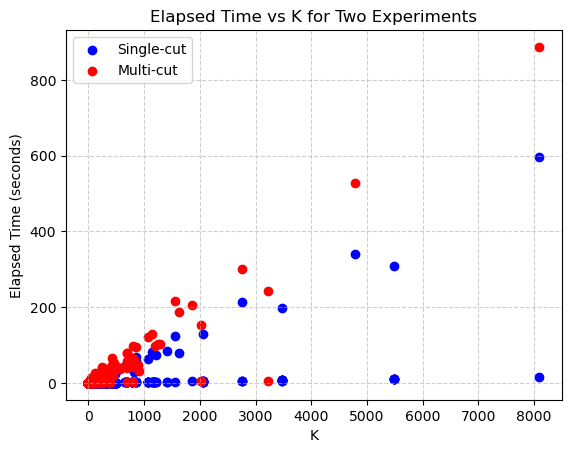

In [110]:


# Scatter plot of both series
plt.scatter(df_single['K'], df_single['elapsedT'], color='blue', label='Single-cut')
plt.scatter(df_mult['K'], df_mult['elapsedT'], color='red', label='Multi-cut')

# Labels, title, legend
plt.xlabel('K')
plt.ylabel('Elapsed Time (seconds)')
plt.title('Elapsed Time vs K for Two Experiments')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [113]:
df_mult[(df_mult.elapsedT<100)&(df_mult.K>100)]

,Status,iiter,total_time,b,ObjVal,LB,x_sol,Kbar,K,Ins,elapsedT,OptGap
75,I,13,17.512311,10,276.319336,273.289062,[ 0 1 2 29 57 105 129 136 148 150],94,111,4,0.977728,1.096656
76,I,14,18.490039,10,276.302734,273.289062,[ 0 2 29 57 81 105 129 136 148 150],111,111,4,11.095461,1.090714
108,I,16,20.951366,10,332.424805,290.311523,[ 2 6 48 54 55 101 113 171 183 202],58,106,16,6.583836,12.668513
109,I,17,27.535202,10,332.403900,301.779907,[ 2 6 48 54 55 101 113 171 183 202],82,147,16,8.912451,9.212886
110,I,18,36.447653,10,332.390747,311.300934,[ 2 6 48 54 55 101 113 171 183 202],110,202,16,11.623596,6.344886
...,...,...,...,...,...,...,...,...,...,...,...,...
453,I,21,140.179149,10,232.181320,229.272217,[ 2 5 6 52 76 79 199 218 226 235],586,807,56,64.815990,1.252945
474,I,20,29.256871,10,228.048218,224.469116,[ 0 4 50 80 149 152 177 189 190 197],114,149,76,12.765341,1.569449
475,I,21,42.022212,10,227.945312,225.043274,[ 0 4 50 80 149 152 155 177 190 197],180,239,76,1.165972,1.273129
476,I,22,43.188184,10,227.939209,225.043274,[ 0 4 50 80 149 152 177 189 190 197],239,239,76,26.384596,1.270486
